# Customer Retention & Revenue Leakage Analysis
## Phase 3 — Data Cleaning

**Dataset:** Online Retail II (UCI / Kaggle)  
**Objective:** Clean raw transactional data and engineer features for downstream SQL and Python analysis.

---
### Notebook Structure
1. Environment Setup
2. Load Raw Data
3. Initial Exploration
4. Data Quality Assessment
5. Cleaning Steps
6. Feature Engineering
7. Export Cleaned Data
8. Cleaning Summary Report

## 1. Environment Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Display settings 
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899']
sns.set_palette(PALETTE)

print('Libraries loaded successfully')

 Libraries loaded successfully


## 2. Load Raw Data

In [21]:
DATA_PATH = 'Data/online_retail_II.csv'  
OUTPUT_PATH = 'Data/Cleaned_Retail.csv'

df_raw = pd.read_csv(DATA_PATH, dtype={'Customer ID': str})

# Standardise column names: remove spaces
df_raw.columns = df_raw.columns.str.strip().str.replace(' ', '')

# Now column is "CustomerID" (space removed)
print(f'Raw data loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

Raw data loaded: 1,067,371 rows × 8 columns


## 3. Exploration

In [23]:
# Basic shape and types 
print('=== DATASET DIMENSIONS ===')
print(f'Rows   : {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')
print(f'Memory : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB\n')

print('=== COLUMN TYPES ===')
print(df_raw.dtypes)

=== DATASET DIMENSIONS ===
Rows   : 1,067,371
Columns: 8
Memory : 456.5 MB

=== COLUMN TYPES ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
CustomerID      object
Country         object
dtype: object


In [24]:
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [28]:
# statistical summary
df_raw.describe(include = 'all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1067371,1067371,1062989,"1,067,371.00",1067371,"1,067,371.00",824364,1067371
unique,53628,5305,5698,NaN,NaN,NaN,5942,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,17841.0,United Kingdom
freq,1350,5829,5918,NaN,NaN,NaN,13097,981330
mean,NaN,NaN,NaN,9.94,2011-01-02 21:13:55.394028544,4.65,NaN,NaN
min,NaN,NaN,NaN,"-80,995.00",2009-12-01 07:45:00,"-53,594.36",NaN,NaN
25%,NaN,NaN,NaN,1.00,2010-07-09 09:46:00,1.25,NaN,NaN
50%,NaN,NaN,NaN,3.00,2010-12-07 15:28:00,2.10,NaN,NaN
75%,NaN,NaN,NaN,10.00,2011-07-22 10:23:00,4.15,NaN,NaN
max,NaN,NaN,NaN,"80,995.00",2011-12-09 12:50:00,"38,970.00",NaN,NaN


In [26]:
# Date range 
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
print(f'Date range: {df_raw["InvoiceDate"].min().date()}  →  {df_raw["InvoiceDate"].max().date()}')
print(f'Span      : {(df_raw["InvoiceDate"].max() - df_raw["InvoiceDate"].min()).days} days')

Date range: 2009-12-01  →  2011-12-09
Span      : 738 days


## 4. Data Quality

In [30]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

quality_report = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_pct,
    'Dtype': df_raw.dtypes
}).sort_values('Missing_Count', ascending=False)

print('=== MISSING VALUE REPORT ===')
print(quality_report)


=== MISSING VALUE REPORT ===
             Missing_Count  Missing_%           Dtype
CustomerID          243007      22.77          object
Description           4382       0.41          object
Invoice                  0       0.00          object
StockCode                0       0.00          object
Quantity                 0       0.00           int64
InvoiceDate              0       0.00  datetime64[ns]
Price                    0       0.00         float64
Country                  0       0.00          object


In [31]:
# Duplicate check
dup_count = df_raw.duplicated().sum()
print(f'Duplicate rows: {dup_count:,} ({dup_count/len(df_raw)*100:.2f}%)')

Duplicate rows: 34,335 (3.22%)


In [32]:
# Cancelled orders 
cancelled = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelled orders: {len(cancelled):,} ({len(cancelled)/len(df_raw)*100:.2f}%)')
print(f'Revenue in cancellations: £{(cancelled["Quantity"] * cancelled["Price"]).sum():,.2f}')

Cancelled orders: 19,494 (1.83%)
Revenue in cancellations: £-1,526,667.86


In [33]:
#  Negative / zero quantity and price 
neg_qty   = df_raw[df_raw['Quantity'] <= 0]
zero_price = df_raw[df_raw['Price'] <= 0]

print(f'Rows with Quantity ≤ 0 : {len(neg_qty):,}')
print(f'Rows with Price ≤ 0   : {len(zero_price):,}')

Rows with Quantity ≤ 0 : 22,950
Rows with Price ≤ 0   : 6,207


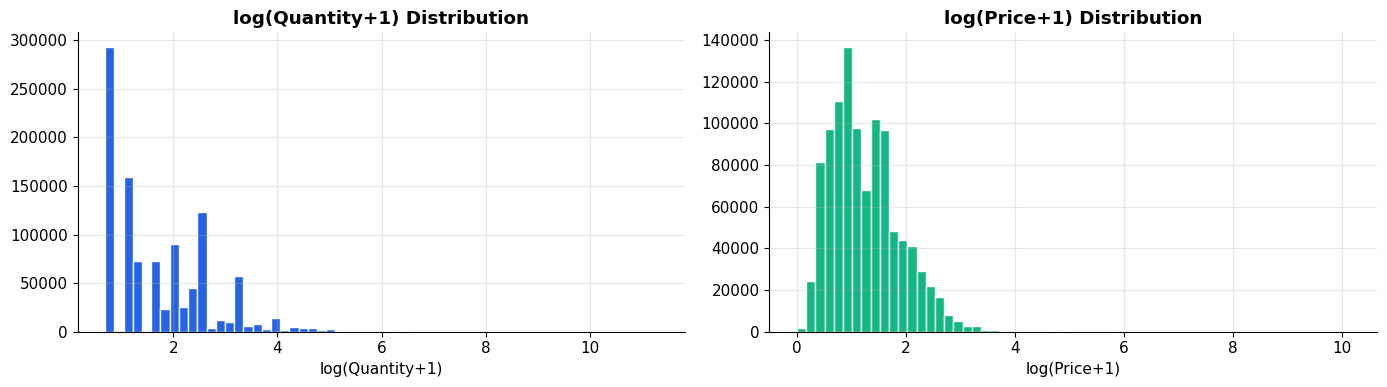

Quantity statistics (positive only):
count   1,041,671.00
mean           10.96
std           126.51
min             1.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00

Price statistics (positive only):
count   1,041,671.00
mean            4.08
std            51.45
min             0.00
25%             1.25
50%             2.10
75%             4.13
max        25,111.09


In [34]:
# Outlier check: Quantity and Price 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Filter to positive values for visualisation
pos = df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)]

axes[0].hist(np.log1p(pos['Quantity']), bins=60, color=PALETTE[0], edgecolor='white')
axes[0].set_title('log(Quantity+1) Distribution', fontweight='bold')
axes[0].set_xlabel('log(Quantity+1)')

axes[1].hist(np.log1p(pos['Price']), bins=60, color=PALETTE[1], edgecolor='white')
axes[1].set_title('log(Price+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price+1)')

plt.tight_layout()
plt.show()

print('Quantity statistics (positive only):')
print(pos['Quantity'].describe().to_string())
print('\nPrice statistics (positive only):')
print(pos['Price'].describe().to_string())

## 5. Cleaning Data

In [35]:
# Making copy first
df = df_raw.copy()
initial_rows = len(df)
print(f'Starting rows: {initial_rows:,}')

cleaning_log = []   # track each step

Starting rows: 1,067,371


In [36]:
# Step 1: Remove duplicates 
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
cleaning_log.append(('Remove duplicates', before, len(df), removed))
print(f'[1] Removed {removed:,} duplicate rows → {len(df):,} rows remaining')

[1] Removed 34,335 duplicate rows → 1,033,036 rows remaining


In [37]:
# Step 2: Drop rows with null CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
removed = before - len(df)
cleaning_log.append(('Drop null CustomerID', before, len(df), removed))
print(f'[2] Removed {removed:,} rows with missing CustomerID → {len(df):,} rows remaining')

[2] Removed 235,151 rows with missing CustomerID → 797,885 rows remaining


In [38]:
# Step 3: Drop rows with null Description 
before = len(df)
df = df.dropna(subset=['Description'])
removed = before - len(df)
cleaning_log.append(('Drop null Description', before, len(df), removed))
print(f'[3] Removed {removed:,} rows with missing Description → {len(df):,} rows remaining')

[3] Removed 0 rows with missing Description → 797,885 rows remaining


In [39]:
# Step 4: Remove cancelled orders (Invoice starts with 'C') 
before = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
removed = before - len(df)
cleaning_log.append(('Remove cancellations', before, len(df), removed))
print(f'[4] Removed {removed:,} cancelled orders → {len(df):,} rows remaining')

[4] Removed 18,390 cancelled orders → 779,495 rows remaining


In [40]:
# Step 5: Remove negative or zero Quantity
before = len(df)
df = df[df['Quantity'] > 0]
removed = before - len(df)
cleaning_log.append(('Remove Quantity ≤ 0', before, len(df), removed))
print(f'[5] Removed {removed:,} rows with Quantity ≤ 0 → {len(df):,} rows remaining')

[5] Removed 0 rows with Quantity ≤ 0 → 779,495 rows remaining


In [41]:
# Step 6: Remove zero or negative Price 
before = len(df)
df = df[df['Price'] > 0]
removed = before - len(df)
cleaning_log.append(('Remove Price ≤ 0', before, len(df), removed))
print(f'[6] Removed {removed:,} rows with Price ≤ 0 → {len(df):,} rows remaining')

[6] Removed 70 rows with Price ≤ 0 → 779,425 rows remaining


In [42]:
# Step 7: Handle extreme outliers (99.9th percentile cap) 
qty_cap   = df['Quantity'].quantile(0.999)
price_cap = df['Price'].quantile(0.999)

before = len(df)
df = df[(df['Quantity'] <= qty_cap) & (df['Price'] <= price_cap)]
removed = before - len(df)
cleaning_log.append(('Cap outliers (99.9th pct)', before, len(df), removed))
print(f'[7] Removed {removed:,} extreme outliers (qty cap={qty_cap:.0f}, price cap={price_cap:.2f}) → {len(df):,} rows remaining')

[7] Removed 1,513 extreme outliers (qty cap=576, price cap=49.95) → 777,912 rows remaining


In [43]:
# Cleaning summary
log_df = pd.DataFrame(cleaning_log, columns=['Step', 'Rows_Before', 'Rows_After', 'Removed'])
log_df['Removed_%'] = (log_df['Removed'] / initial_rows * 100).round(2)

print('\n=== CLEANING SUMMARY ===')
print(log_df.to_string(index=False))
print(f'\nTotal removed : {initial_rows - len(df):,} ({(initial_rows - len(df))/initial_rows*100:.1f}%)')
print(f'Final dataset : {len(df):,} rows')


=== CLEANING SUMMARY ===
                     Step  Rows_Before  Rows_After  Removed  Removed_%
        Remove duplicates      1067371     1033036    34335       3.22
     Drop null CustomerID      1033036      797885   235151      22.03
    Drop null Description       797885      797885        0       0.00
     Remove cancellations       797885      779495    18390       1.72
      Remove Quantity ≤ 0       779495      779495        0       0.00
         Remove Price ≤ 0       779495      779425       70       0.01
Cap outliers (99.9th pct)       779425      777912     1513       0.14

Total removed : 289,459 (27.1%)
Final dataset : 777,912 rows


## 6. Feature Engineering

In [44]:
# Ensure correct types 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(str).str.strip()
df['StockCode']   = df['StockCode'].astype(str).str.strip()
df['Description'] = df['Description'].str.strip().str.upper()
df['Country']     = df['Country'].str.strip()

print(' Data types confirmed')

 Data types confirmed


In [46]:
# Revenue per line item 
df['Revenue'] = df['Quantity'] * df['Price']
print(f'Total Revenue: £{df["Revenue"].sum():,.2f}')

Total Revenue: £16,171,051.45


In [47]:
# Date-derived features
reference_date = df['InvoiceDate'].max()   # last transaction date

df['DaysSincePurchase'] = (reference_date - df['InvoiceDate']).dt.days
df['OrderMonth']        = df['InvoiceDate'].dt.to_period('M')
df['OrderYear']         = df['InvoiceDate'].dt.year
df['OrderDayOfWeek']    = df['InvoiceDate'].dt.day_name()
df['OrderHour']         = df['InvoiceDate'].dt.hour
df['OrderQuarter']      = df['InvoiceDate'].dt.quarter

print(f'Reference date: {reference_date.date()}')
print('\nNew columns added: DaysSincePurchase, OrderMonth, OrderYear, OrderDayOfWeek, OrderHour, OrderQuarter')

Reference date: 2011-12-09

New columns added: DaysSincePurchase, OrderMonth, OrderYear, OrderDayOfWeek, OrderHour, OrderQuarter


In [48]:
# Order-level aggregate (for invoice totals) 
order_totals = df.groupby('Invoice')['Revenue'].sum().reset_index()
order_totals.columns = ['Invoice', 'OrderTotal']
df = df.merge(order_totals, on='Invoice', how='left')

print('OrderTotal column added')

OrderTotal column added


In [49]:
# Quick sanity check on engineered features
df[['CustomerID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price',
    'Revenue', 'OrderTotal', 'DaysSincePurchase', 'OrderMonth']].head(8)

,CustomerID,Invoice,InvoiceDate,Quantity,Price,Revenue,OrderTotal,DaysSincePurchase,OrderMonth
0,13085.0,489434,2009-12-01 07:45:00,12,6.95,83.40,505.30,738,2009-12
1,13085.0,489434,2009-12-01 07:45:00,12,6.75,81.00,505.30,738,2009-12
2,13085.0,489434,2009-12-01 07:45:00,12,6.75,81.00,505.30,738,2009-12
3,13085.0,489434,2009-12-01 07:45:00,48,2.10,100.80,505.30,738,2009-12
4,13085.0,489434,2009-12-01 07:45:00,24,1.25,30.00,505.30,738,2009-12
5,13085.0,489434,2009-12-01 07:45:00,24,1.65,39.60,505.30,738,2009-12
6,13085.0,489434,2009-12-01 07:45:00,24,1.25,30.00,505.30,738,2009-12
7,13085.0,489434,2009-12-01 07:45:00,10,5.95,59.50,505.30,738,2009-12


## 7. Export Clean Data

In [50]:
# Final column order 
final_cols = [
    'Invoice', 'StockCode', 'Description', 'Quantity', 'Price',
    'InvoiceDate', 'CustomerID', 'Country',
    'Revenue', 'OrderTotal', 'DaysSincePurchase',
    'OrderMonth', 'OrderYear', 'OrderQuarter', 'OrderDayOfWeek', 'OrderHour'
]

df_clean = df[final_cols].copy()

# Convert Period to string so CSV can serialise it
df_clean['OrderMonth'] = df_clean['OrderMonth'].astype(str)

df_clean.to_csv(OUTPUT_PATH, index=False)
print(f' Cleaned data exported → {OUTPUT_PATH}')
print(f'   Rows   : {len(df_clean):,}')
print(f'   Columns: {df_clean.shape[1]}')
print(f'   Size   : {os.path.getsize(OUTPUT_PATH)/1e6:.1f} MB')

 Cleaned data exported → Data/Cleaned_Retail.csv
   Rows   : 777,912
   Columns: 16
   Size   : 106.5 MB


In [51]:
# Final schema preview
print('=== FINAL COLUMN SCHEMA ===')
schema = pd.DataFrame({
    'Column': df_clean.columns,
    'Dtype': df_clean.dtypes.values,
    'Non-null': df_clean.notnull().sum().values,
    'Sample': [df_clean[c].iloc[0] for c in df_clean.columns]
})
print(schema.to_string(index=False))

=== FINAL COLUMN SCHEMA ===
           Column          Dtype  Non-null                              Sample
          Invoice         object    777912                              489434
        StockCode         object    777912                               85048
      Description         object    777912 15CM CHRISTMAS GLASS BALL 20 LIGHTS
         Quantity          int64    777912                                  12
            Price        float64    777912                                6.95
      InvoiceDate datetime64[ns]    777912                 2009-12-01 07:45:00
       CustomerID         object    777912                             13085.0
          Country         object    777912                      United Kingdom
          Revenue        float64    777912                               83.40
       OrderTotal        float64    777912                              505.30
DaysSincePurchase          int64    777912                                 738
       OrderMonth       